# QVAE-Mole

Reimplements the core model from [wuhuaijin/QVAE](https://github.com/wuhuaijin/QVAE) — *"QVAE-Mole:
The Quantum VAE with Spherical Latent Variable Learning for 3-D Molecule Generation"* (NeurIPS
2024) — mirroring the structure of `vae.ipynb` / `qvae.ipynb` / `svae.ipynb` (data → model → train →
sample → reconstructions → interpolations).

The official repo is a PyTorch + [TorchQuantum](https://github.com/mit-han-lab/torchquantum)
research codebase (`models/model.py::DrugQAE`, `main.py`, `generate.py`) wired to the QM9 3-D
molecule dataset: it amplitude-encodes each molecule's atom coordinates/types, runs a
hardware-efficient quantum autoencoder, and scores generation with molecule-specific metrics
(validity / bond-length MMD via a focal atom-type loss). TorchQuantum must be cloned from MIT Han
Lab and is not cleanly pip-installable, and the model and losses are tied to the molecule pipeline,
so instead of importing it directly this notebook ports its load-bearing pieces — the RZ-RY-RZ +
ring-CRX hardware-efficient ansatz (`DrugQAE`'s encoder/decoder layers), the
probability-marginalization bottleneck (`DrugQAE.forward`'s reshape/sum over the "bottleneck"
qubits), the von Mises-Fisher spherical-latent sampler (`DrugQAE.sampling_vmf`), and the fidelity
reconstruction objective (`main.py::fidelity_loss`) — as plain `torch` statevector ops, verbatim in
spirit, wired into the same MNIST pipeline used elsewhere in this survey. TorchQuantum already
trains this model with Adam via autograd, so unlike `qvae.ipynb` there is **no** optimizer swap:
every op here (RZ/RY/RX rotations, controlled-RX, amplitude marginalization, vMF tangent-normal
sampling) is differentiable and trained with Adam exactly as in the original.

Unlike a standard VAE — and unlike the maximally-mixed-state regularizer of `qvae.ipynb` — the
latent here lives on a **hypersphere**: the encoder produces a unit vector `mu`, and the
reparameterization draws a sample from a **von Mises-Fisher** distribution `vMF(mu, kappa)`
concentrated around it. The concentration `kappa` plays the role of `beta`: because the
vMF-to-uniform KL depends only on the (fixed) `kappa` it is constant and drops out of the gradient,
so the training objective is reconstruction fidelity alone, with `kappa` controlling how much latent
noise regularizes the encoder.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torchvision.datasets as datasets

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float64)  # statevector / fidelity math is numerically sensitive

## Data

Same MNIST split used by `vae.ipynb`, amplitude-encoded into pure quantum statevectors. The original
repo amplitude-encodes each molecule's `input_dim`-length feature vector with TorchQuantum's
`AmplitudeEncoder` (`DrugQAE.encoder`); we do the same with MNIST. Simulating dense `n`-qubit
circuits is exponential in the qubit count, so — matching the small feature vectors the original
encodes (QM9 uses `input_dim=73` on `n_qbits=7`) — we downsample each 28x28 image to 8x8=64=2^6
pixels (`n_qbits=6`) and L2-normalize each flattened image to a unit vector. A unit vector is a valid
statevector, and its squared amplitudes are the pixel "probabilities".

In [2]:
mnist_trainset = datasets.MNIST(root='../../data', train=True, download=True, transform=None)

n_qbits = 6
res = 2 ** (n_qbits // 2)  # 8x8 = 64 = 2^6

def to_amplitude_states(images):
    x = images.reshape(-1, 1, 28, 28).double() / 255.
    x = nn.functional.adaptive_avg_pool2d(x, (res, res)).reshape(-1, res * res)
    x = x + 1e-6  # avoid an exact all-zero (unnormalizable) state
    x = x / x.norm(dim=1, keepdim=True)
    return x

train_dataset = to_amplitude_states(mnist_trainset.data[:-10000])
eval_dataset = to_amplitude_states(mnist_trainset.data[-10000:])

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.31MB/s]


## Hardware-efficient ansatz (RZ-RY-RZ + ring CRX)

Ported from `DrugQAE`'s encoder/decoder layers in `models/model.py`: `n_blocks + 1` blocks, each a
per-qubit `RZ·RY·RZ` Euler rotation, with a ring of controlled-`RX` gates (qubit `i` controls qubit
`(i+1) % n`) entangling consecutive blocks. TorchQuantum applies these gates to a statevector on a
`QuantumDevice`; here we build the equivalent dense `2^n x 2^n` unitaries (Kronecker products of
single-/two-qubit gates) and apply them to a batch of statevectors as `psi -> U psi`. The decoder
uses an independent parameter set and runs the blocks in reverse (rotation order `RZ·RY·RZ` reversed,
entangler applied before the rotations), matching `DrugQAE`'s decode loop.

In [3]:
def embed_gate(gate, qubit, n_qubits):
    """Embed a (2, 2) gate acting on `qubit` into the full 2^n x 2^n space via Kronecker products."""
    eye = torch.eye(2, dtype=torch.complex128, device=gate.device)
    mats = [eye] * n_qubits
    mats[qubit] = gate
    out = mats[0]
    for m in mats[1:]:
        out = torch.kron(out, m)
    return out

def rz_gate(theta):
    t = theta.to(torch.complex128)
    zero = torch.zeros((), dtype=torch.complex128, device=theta.device)
    return torch.stack([torch.stack([torch.exp(-0.5j * t), zero]),
                        torch.stack([zero, torch.exp(0.5j * t)])])

def ry_gate(theta):
    c, s = torch.cos(theta / 2), torch.sin(theta / 2)
    return torch.stack([torch.stack([c, -s]), torch.stack([s, c])]).to(torch.complex128)

def rx_gate(theta):
    c = torch.cos(theta / 2).to(torch.complex128)
    s = torch.sin(theta / 2).to(torch.complex128)
    return torch.stack([torch.stack([c, -1j * s]), torch.stack([-1j * s, c])])

def crx_unitary(theta, control, target, n_qubits):
    """Controlled-RX: apply RX(theta) to `target` when `control` is |1>.
    Built as P0_c (x) I  +  P1_c (x) RX_target, with P0 = |0><0|, P1 = |1><1|."""
    dev = theta.device
    p0 = torch.tensor([[1, 0], [0, 0]], dtype=torch.complex128, device=dev)
    p1 = torch.tensor([[0, 0], [0, 1]], dtype=torch.complex128, device=dev)
    return embed_gate(p0, control, n_qubits) + \
        embed_gate(p1, control, n_qubits) @ embed_gate(rx_gate(theta), target, n_qubits)

def apply_unitary(U, state):
    """state: (B, 2^n) complex statevectors -> (B, 2^n), i.e. U @ psi per sample."""
    return torch.einsum('ij,bj->bi', U, state)

def amplitude_encode(vec, n_qubits):
    """TorchQuantum-style AmplitudeEncoder: zero-pad `vec` up to 2^n, L2-normalize, cast to complex.
    A latent of dim 2^(n - bottleneck) is thus padded into the first amplitudes of the n-qubit register."""
    b, d = vec.shape
    dim = 2 ** n_qubits
    if d < dim:
        vec = torch.cat([vec, torch.zeros(b, dim - d, dtype=vec.dtype, device=vec.device)], dim=1)
    vec = vec / vec.norm(dim=1, keepdim=True)
    return vec.to(torch.complex128)

## Probability-marginalization bottleneck

Ported from the reshape/sum in `DrugQAE.forward`. After the encoder circuit, the repo reads the
statevector's squared amplitudes (a probability distribution over the `2^n` basis states), reshapes
to `(2^(n - bottleneck), 2^bottleneck)` and sums over the last axis — classically marginalizing out
the `bottleneck_qbits` "trash" qubits — then takes the square root to recover a
`2^(n - bottleneck)`-dimensional amplitude vector. This unit vector is the latent mean `mu`. (It is a
probability marginal, not a quantum partial trace: it discards the kept qubits' phase/coherence,
exactly as the original does.)

In [4]:
def marginalize_bottleneck(state, n_qubits, bottleneck_qbits):
    """state: (B, 2^n) -> (B, 2^(n - bottleneck_qbits)) real latent amplitudes."""
    latent_dim = 2 ** (n_qubits - bottleneck_qbits)
    probs = state.abs() ** 2
    probs = probs.reshape(-1, latent_dim, 2 ** bottleneck_qbits).sum(dim=-1)
    return probs.sqrt()

## Spherical latent: von Mises-Fisher sampling

The defining novelty of the paper, ported from `DrugQAE.sampling_vmf`. Where a Gaussian VAE draws
`z = mu + sigma * eps`, here the latent lives on the unit hypersphere and the reparameterization
draws `z ~ vMF(mu, kappa)` — the spherical analogue of a Gaussian, concentrated around the encoder's
unit vector `mu` with concentration `kappa`. Sampling uses the standard tangent-normal (Ulrich/Wood)
decomposition: draw the cosine `w` to `mu` from its marginal density
`p(w) ∝ exp(kappa·w)·(1 - w^2)^((d-3)/2)` by inverse-CDF, draw a direction `nu` uniform on the sphere
orthogonal to `mu`, and return `z = w·mu + sqrt(1 - w^2)·nu`. Gradients flow to the encoder through
`mu` (in both `w·mu` and the `nu` projection); the sampling of `w` is the non-differentiable "noise",
like `eps` in the Gaussian trick.

The original rebuilds the inverse-CDF grid on every forward call; since it depends only on `kappa`
and the latent dimension (both fixed), we precompute it once in `__init__` — the same optimization in
spirit as vectorizing the partial trace in `qvae.ipynb`, with the math unchanged.

In [5]:
def build_vmf_cdf(kappa, dim, grid=200000):
    """Inverse-CDF table for the vMF cosine marginal p(w) ~ exp(kappa*w) * (1 - w^2)^((dim-3)/2)."""
    eps = 1e-7
    x = torch.linspace(-1 + eps, 1 - eps, grid, dtype=torch.float64)
    y = kappa * x + torch.log(1 - x ** 2) * (dim - 3) / 2
    cdf = torch.cumsum(torch.exp(y - y.max()), dim=0)
    return x, cdf / cdf[-1].clone()

def sample_vmf(mu, vmf_x, vmf_cdf):
    """Draw z ~ vMF(mu, kappa) via the tangent-normal decomposition (mu: (B, d) unit vectors)."""
    u = torch.rand(mu.size(0), dtype=torch.float64)
    w = np.interp(u.numpy(), vmf_cdf.cpu().numpy(), vmf_x.cpu().numpy())
    w = torch.tensor(w, dtype=mu.dtype, device=mu.device).unsqueeze(1)
    eps = torch.randn_like(mu)
    nu = eps - (eps * mu).sum(dim=1, keepdim=True) * mu       # component orthogonal to mu
    nu = nn.functional.normalize(nu, p=2, dim=-1)
    return w * mu + (1 - w ** 2).clamp(min=0).sqrt() * nu

## Model

`n_qbits = 6` total qubits, with `bottleneck_qbits` (default 2, matching the original's
`--bottleneck_qbits`) marginalized out after the encoder to form the spherical latent of dimension
`2^(n_qbits - bottleneck_qbits) = 16`. The decoder amplitude-encodes the (zero-padded) latent unit
vector back into all `n_qbits` qubits and applies its own reverse ansatz, reading the reconstruction
straight off the output statevector's amplitudes. `n_blocks` sets the ansatz depth (the repo default
is 10; we use 3 here to keep single-CPU simulation snappy, matching the modest budgets of the other
notebooks in this survey).

In [6]:
class DrugQAE(nn.Module):
    """Statevector port of models/model.py::DrugQAE. `n_qbits` total qubits; `bottleneck_qbits`
    are marginalized after the encoder to form the spherical latent of dim 2^(n_qbits - bottleneck_qbits)."""
    def __init__(self, n_qbits=6, n_blocks=3, bottleneck_qbits=2, kappa=20.0):
        super().__init__()
        self.n_qbits = n_qbits
        self.n_blocks = n_blocks
        self.bottleneck_qbits = bottleneck_qbits
        self.latent_dim = 2 ** (n_qbits - bottleneck_qbits)
        self.kappa = kappa

        # per-qubit RZ-RY-RZ angles for n_blocks+1 blocks, and CRX angles for the n_blocks entangling rings
        rot = lambda: nn.Parameter(0.1 * torch.randn(n_blocks + 1, n_qbits))
        ent = lambda: nn.Parameter(0.1 * torch.randn(n_blocks, n_qbits))
        self.enc_rz1, self.enc_ry, self.enc_rz2, self.enc_crx = rot(), rot(), rot(), ent()
        self.dec_rz1, self.dec_ry, self.dec_rz2, self.dec_crx = rot(), rot(), rot(), ent()

        vmf_x, vmf_cdf = build_vmf_cdf(kappa, self.latent_dim)
        self.register_buffer("vmf_x", vmf_x)
        self.register_buffer("vmf_cdf", vmf_cdf)

    def encoder_unitary(self):
        n = self.n_qbits
        U = torch.eye(2 ** n, dtype=torch.complex128, device=self.enc_ry.device)
        for k in range(self.n_blocks + 1):
            for i in range(n):
                U = embed_gate(rz_gate(self.enc_rz1[k, i]), i, n) @ U
                U = embed_gate(ry_gate(self.enc_ry[k, i]), i, n) @ U
                U = embed_gate(rz_gate(self.enc_rz2[k, i]), i, n) @ U
            if k != self.n_blocks:
                for i in range(n):
                    U = crx_unitary(self.enc_crx[k, i], i, (i + 1) % n, n) @ U
        return U

    def decoder_unitary(self):
        n = self.n_qbits
        U = torch.eye(2 ** n, dtype=torch.complex128, device=self.dec_ry.device)
        for k in range(self.n_blocks, -1, -1):
            if k != self.n_blocks:
                for i in range(n - 1, -1, -1):
                    U = crx_unitary(self.dec_crx[k, i], i, (i + 1) % n, n) @ U
            for i in range(n):
                U = embed_gate(rz_gate(self.dec_rz2[k, i]), i, n) @ U
                U = embed_gate(ry_gate(self.dec_ry[k, i]), i, n) @ U
                U = embed_gate(rz_gate(self.dec_rz1[k, i]), i, n) @ U
        return U

    def encode(self, x):
        """x: (B, 2^n) input amplitudes -> (B, latent_dim) unit-vector latent means mu."""
        state = apply_unitary(self.encoder_unitary(), amplitude_encode(x, self.n_qbits))
        return marginalize_bottleneck(state, self.n_qbits, self.bottleneck_qbits)

    def decode(self, z):
        """z: (B, latent_dim) latent unit vectors -> (B, 2^n) reconstructed amplitudes (>= 0)."""
        state = apply_unitary(self.decoder_unitary(), amplitude_encode(z, self.n_qbits))
        return state.abs()

    def forward(self, x):
        mu = self.encode(x)
        z = sample_vmf(mu, self.vmf_x, self.vmf_cdf)
        return mu, self.decode(z)

## Objective: fidelity reconstruction

Ported from `main.py::fidelity_loss`: `1 - <x|recon>^2`, the infidelity of the overlap between the
input statevector and its reconstruction, averaged over the batch. The paper's full molecule loss
adds QM9-specific atom-type / coordinate terms (`loss_func_qm9`); on MNIST amplitudes the bare
fidelity term is the right analogue and is exactly what the repo defines for the reconstruction
objective.

There is no KL / `beta` term: the spherical prior is uniform on the hypersphere, the vMF-to-uniform
KL depends only on the fixed `kappa`, and a constant does not affect the gradient — so `kappa` alone
sets how much the vMF noise regularizes the latent (larger `kappa` = tighter concentration = less
regularization).

In [7]:
def fidelity_loss(x, recon):
    overlap = torch.einsum('bi,bi->b', x, recon)
    return (1 - overlap ** 2).mean()

model = DrugQAE(n_qbits=n_qbits, n_blocks=3, bottleneck_qbits=2, kappa=20.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 5          # Change this to train the model a bit more
steps_per_epoch = 100   # Change this to train on more data per epoch
batch_size = 32
log_every = 10

train_x = train_dataset.to(device)

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for step in range(steps_per_epoch):
        idx = torch.randint(0, len(train_x), (batch_size,), device=device)
        x = train_x[idx]

        mu, recon = model(x)
        loss = fidelity_loss(x, recon)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        if (step + 1) % log_every == 0:
            print(f"  epoch {epoch + 1}/{num_epochs}  step {step + 1}/{steps_per_epoch}  "
                  f"fidelity_loss={loss.item():.4f}  mean_fidelity={1 - loss.item():.4f}")

    print(f"epoch {epoch + 1}/{num_epochs}  avg loss={epoch_loss / steps_per_epoch:.4f}")

  epoch 1/5  step 10/100  fidelity_loss=0.9209  mean_fidelity=0.0791
  epoch 1/5  step 20/100  fidelity_loss=0.8033  mean_fidelity=0.1967
  epoch 1/5  step 30/100  fidelity_loss=0.6970  mean_fidelity=0.3030
  epoch 1/5  step 40/100  fidelity_loss=0.6974  mean_fidelity=0.3026
  epoch 1/5  step 50/100  fidelity_loss=0.6558  mean_fidelity=0.3442
  epoch 1/5  step 60/100  fidelity_loss=0.6542  mean_fidelity=0.3458
  epoch 1/5  step 70/100  fidelity_loss=0.5897  mean_fidelity=0.4103
  epoch 1/5  step 80/100  fidelity_loss=0.5932  mean_fidelity=0.4068
  epoch 1/5  step 90/100  fidelity_loss=0.5779  mean_fidelity=0.4221
  epoch 1/5  step 100/100  fidelity_loss=0.5830  mean_fidelity=0.4170
epoch 1/5  avg loss=0.6965
  epoch 2/5  step 10/100  fidelity_loss=0.5995  mean_fidelity=0.4005
  epoch 2/5  step 20/100  fidelity_loss=0.5610  mean_fidelity=0.4390
  epoch 2/5  step 30/100  fidelity_loss=0.5669  mean_fidelity=0.4331
  epoch 2/5  step 40/100  fidelity_loss=0.5912  mean_fidelity=0.4088
  epoc

## Visualizing samples

The original samples molecules by drawing a random latent and running only the decoder
(`main.py::generate`: `z = |N(0, I)|`, normalized onto the unit sphere, then `model.generate(z)`). We
do the same here — a random non-negative unit vector on the latent hypersphere, decoded to an image
— the spherical-prior analogue of `NormalSampler` in `vae.ipynb`.

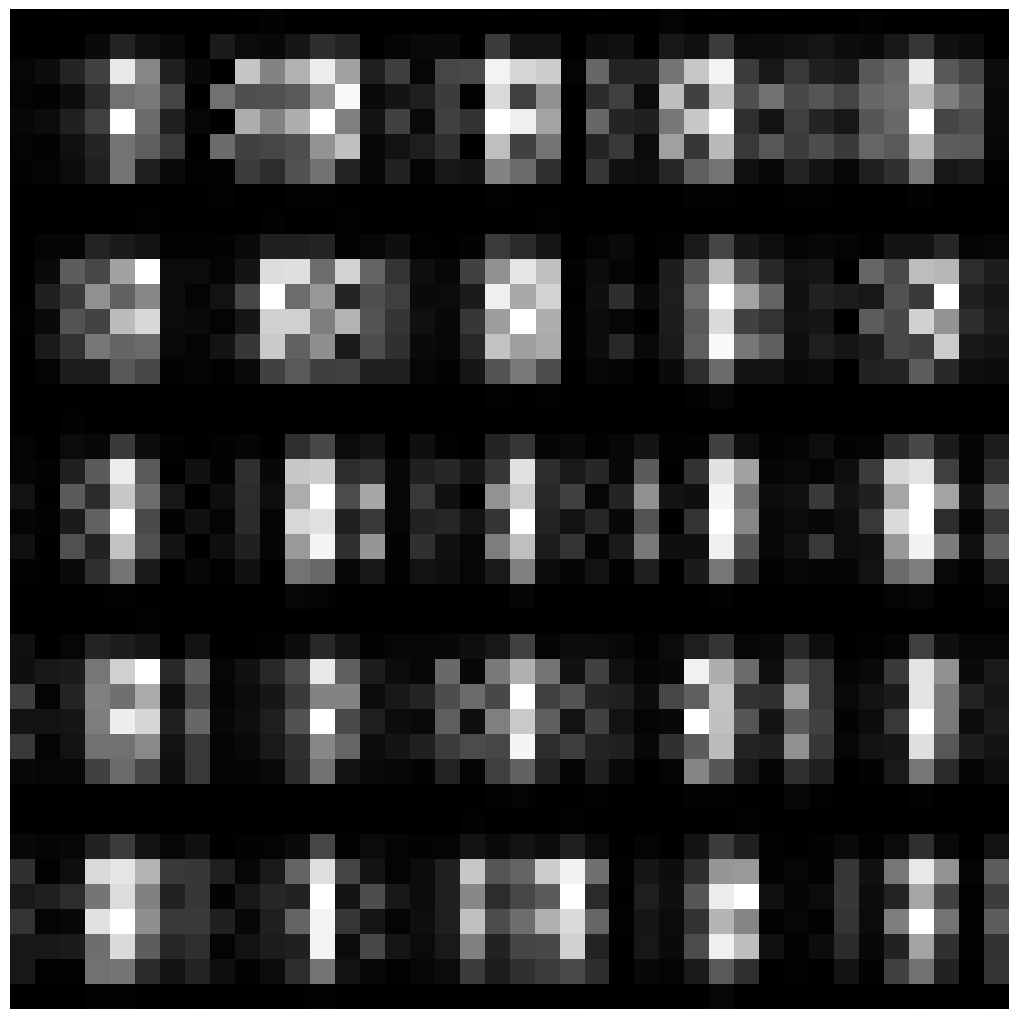

In [8]:
import matplotlib.pyplot as plt

def amplitudes_to_image(recon):
    probs = recon ** 2
    probs = probs / probs.sum(dim=-1, keepdim=True)
    return probs.reshape(-1, res, res)

model.eval()
with torch.no_grad():
    z = torch.randn(25, model.latent_dim, device=device).abs()   # main.py::generate draws |N(0, I)|
    z = z / z.norm(dim=1, keepdim=True)
    gen_data = amplitudes_to_image(model.decode(z)).cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(gen_data[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing reconstructions

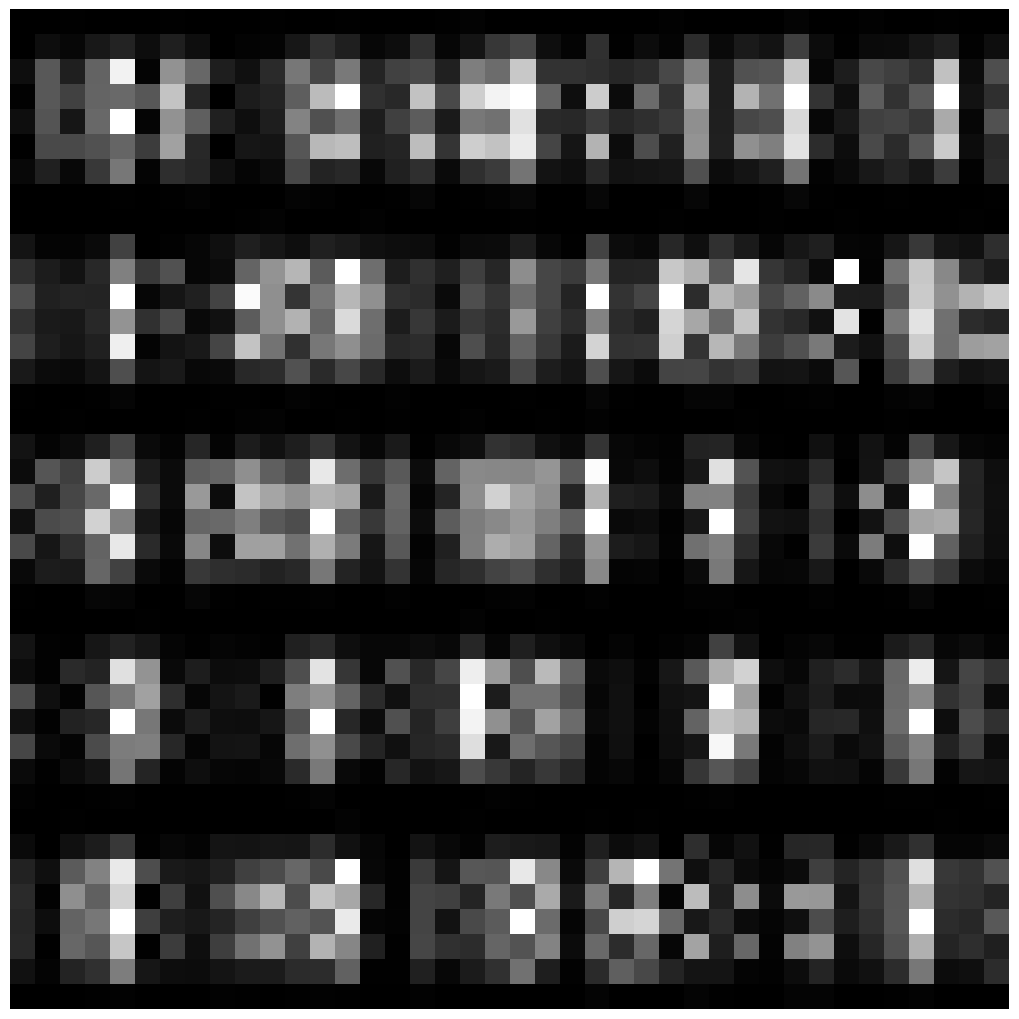

In [9]:
eval_x = eval_dataset[:25].to(device)
with torch.no_grad():
    _, recon = model(eval_x)
    reconstructions = amplitudes_to_image(recon).cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(reconstructions[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

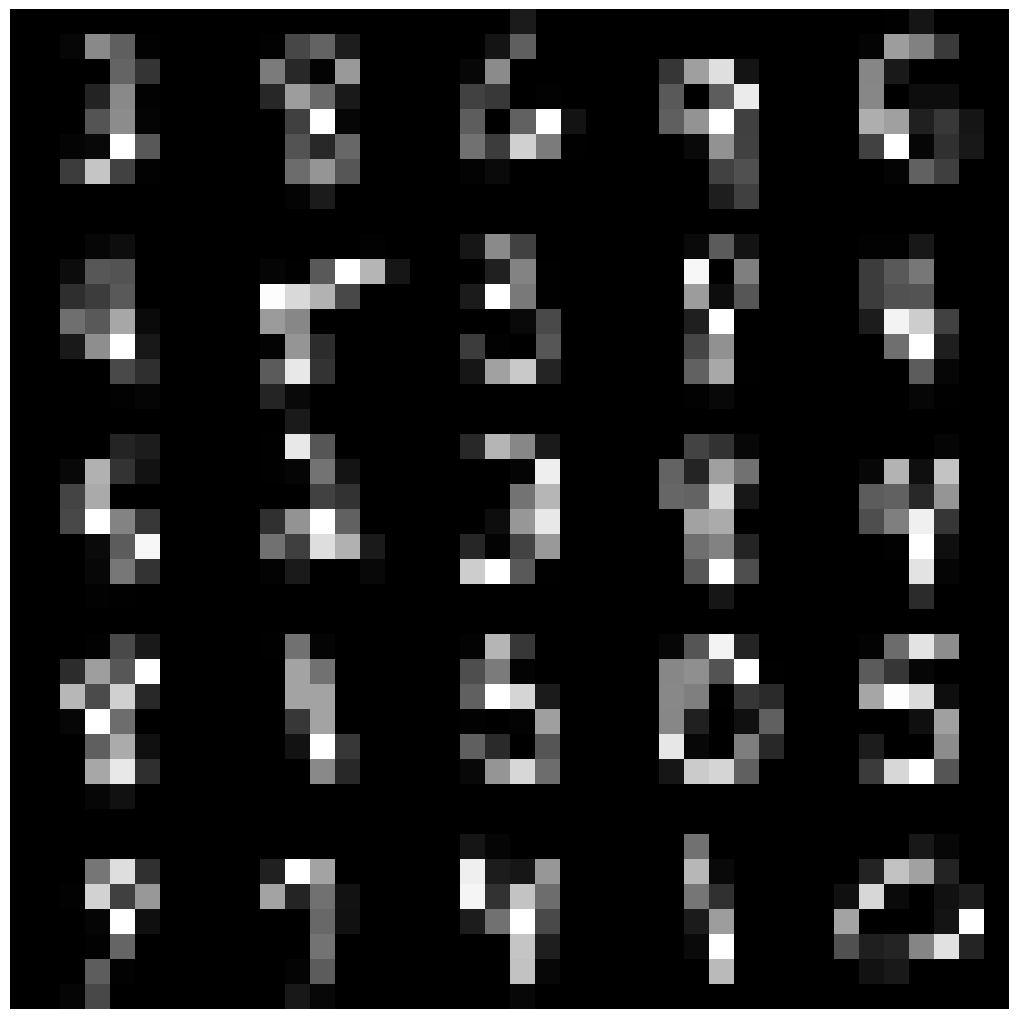

In [10]:
# show the true data
true_images = (eval_x.cpu() ** 2).reshape(-1, res, res)  # amplitudes^2 = pixel probabilities

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(true_images[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing interpolations

Because the latent lives on a hypersphere, the natural analogue of the straight-line latent
interpolation in `vae.ipynb` is **spherical linear interpolation (slerp)** between two encoded latent
unit vectors — staying on the sphere the vMF prior is defined over — decoded at each step.

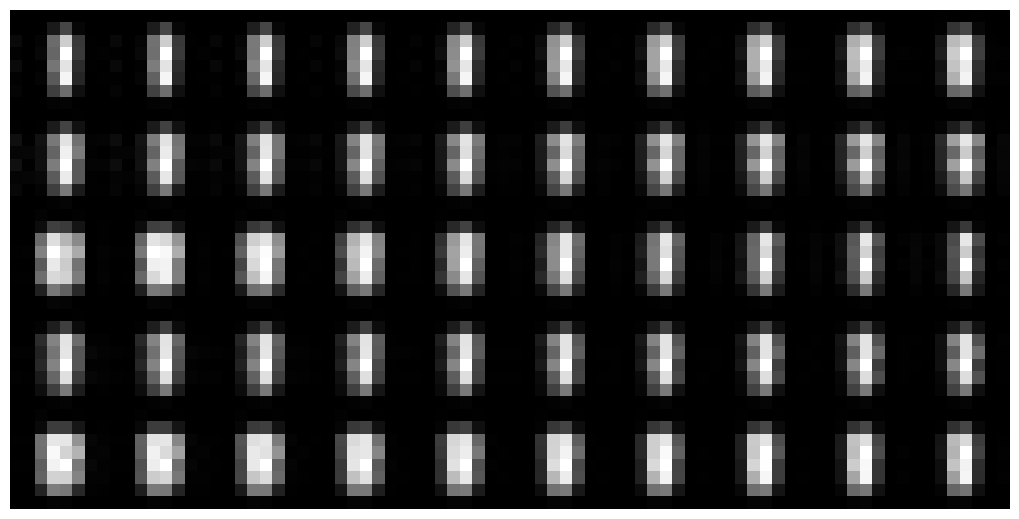

In [11]:
x1 = eval_dataset[:5].to(device)
x2 = eval_dataset[5:10].to(device)

with torch.no_grad():
    z1, z2 = model.encode(x1), model.encode(x2)
    dot = (nn.functional.normalize(z1, dim=1) * nn.functional.normalize(z2, dim=1)).sum(1, keepdim=True).clamp(-1, 1)
    omega = torch.acos(dot)
    sin_omega = torch.sin(omega)

    granularity = 10
    frames = []
    for a in torch.linspace(0, 1, granularity, device=device):
        z = torch.where(sin_omega.abs() < 1e-6,
                        (1 - a) * z1 + a * z2,
                        (torch.sin((1 - a) * omega) / sin_omega) * z1 + (torch.sin(a * omega) / sin_omega) * z2)
        frames.append(model.decode(z))
    interpolations = torch.stack(frames)  # (granularity, 5, 2^n)
    interpolations = amplitudes_to_image(interpolations.reshape(-1, interpolations.shape[-1]))
    interpolations = interpolations.reshape(granularity, 5, res, res).permute(1, 0, 2, 3).cpu()

fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(10, 5))
for i in range(5):
    for j in range(10):
        axes[i][j].imshow(interpolations[i, j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)